**Paso 1: Instalar e importar las librerías necesarias**

In [1]:
import sys
!{sys.executable} -m pip install "tensorflow==2.13.0"
print(sys.executable)
print(sys.version)

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.13.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached keras-2.13.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached tensorboard-2.13.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorflow_estimator-2.13.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached typing_extensions-4.5.0-py3-none-any.whl.metadata (8.5 kB)
Using cached tensorflow-2.13.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (524.2 MB)
Using cached keras-2.13.1-py3-none-any.whl (1.7 MB)
Using cached tensorboard-2.13.0-py3-none-any.whl (5.6 MB)
Using cached tensorflow_estimator-2.13.0-py2.py3-none-any.whl (440 kB)
Using cached typing_extensions-4.5.0-py3-none-any.whl (27 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing

In [2]:
!pip install keras

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install pillow

Defaulting to user installation because normal site-packages is not writeable


In [4]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPool2D,
    Flatten,
    Dense
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

2026-04-20 10:18:15.658286: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 10:18:15.725287: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 10:18:16.395810: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 10:18:16.398396: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 10:18:22.515642: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

**Paso 2: Configuración de parámetros**

In [5]:
DATASET_ORIGINAL = 'train' # Carpeta con las 25.000 imágenes originales
DATASET_PREPARADO = 'dataset' # Carpeta nueva que voy a crear organizando las imágenes
IMG_ANCHO = 224
IMG_ALTO = 224
IMG_FORMA = (224, 224, 3) # Alto x Ancho x Canales de color (3 = RGB)
BATCH_SIZE = 32 # 32 imágenes por lote
PROPORCION_VALIDACION = 0.2 # Del total de imágenes, uso el 80 % para entrenar y el 20 % para validar
EPOCAS = 25
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print('Configuración:')
print(f'- Tamaño de la imagen: {IMG_ANCHO} x {IMG_ALTO} píxeles')
print(f'- Tamaño del lote: {BATCH_SIZE} imágenes')
print(f'- Épocas: {EPOCAS}')

Configuración:
- Tamaño de la imagen: 224 x 224 píxeles
- Tamaño del lote: 32 imágenes
- Épocas: 25


**Paso 3: Organizar el dataset**

In [6]:
def organizar_dataset(carpeta_origen, carpeta_destino, proporcion_val=0.2):
    """
    Organiza las imágenes en subcarpetas por clase (cat/dog)
    y las divide en entrenamiento (80 %) y validación (20 %).
    """
    if os.path.exists(carpeta_destino):
        print(f'La carpeta "{carpeta_destino}" ya existe.')
        return
    
    print('Organizando el dataset...')

    # Creo las 4 subcarpetas necesarias
    for split in ['train', 'validation']:
        for clase in ['cat', 'dog']:
            os.makedirs(os.path.join(carpeta_destino, split, clase), exist_ok=True)
    
    # Obtengo la lista de todas las imágenes
    todas = os.listdir(carpeta_origen)
    gatos = [f for f in todas if f.startswith('cat')]
    perros = [f for f in todas if f.startswith('dog')]

    print(f'Imágenes de gatos: {len(gatos)}')
    print(f'Imágenes de perros: {len(perros)}')

    def copiar_imagenes(lista, clase, carpeta_origen, carpeta_destino, proporcion_val):
        """Copia las imágenes divididas en train y test"""
        random.shuffle(lista)

        # Calculo cuántas imágenes van a test
        n_val = int(len(lista) * proporcion_val)
        
        val_imagenes = lista[:n_val] # Las primeras n_val van a test
        train_imagenes = lista[n_val:] # El resto va a train

        # Copio a test
        for img in val_imagenes:
            src = os.path.join(carpeta_origen, img)
            dst = os.path.join(carpeta_destino, 'validation', clase, img)
            shutil.copy(src, dst)
        
        # Copio a train
        for img in train_imagenes:
            src = os.path.join(carpeta_origen, img)
            dst = os.path.join(carpeta_destino, 'train', clase, img)
            shutil.copy(src, dst)
        
        return len(train_imagenes), len(val_imagenes)
    
    # Copio gatos y perros
    train_gatos, val_gatos = copiar_imagenes(gatos, 'cat', carpeta_origen, carpeta_destino, proporcion_val)
    train_perros, val_perros = copiar_imagenes(perros, 'dog', carpeta_origen, carpeta_destino, proporcion_val)
    
    print(f'\nDataset organizado correctamente:')
    print(f'   Train gatos: {train_gatos} | Train perros: {train_perros} | Total: {train_gatos + train_perros}')
    print(f'   Test gatos: {val_gatos} | Test perros: {val_perros} | Total: {val_gatos + val_perros}')

# Ejecuto la función
organizar_dataset(DATASET_ORIGINAL, DATASET_PREPARADO, PROPORCION_VALIDACION)

La carpeta "dataset" ya existe.


**Paso 4: Visualizar las imágenes**

GATOS


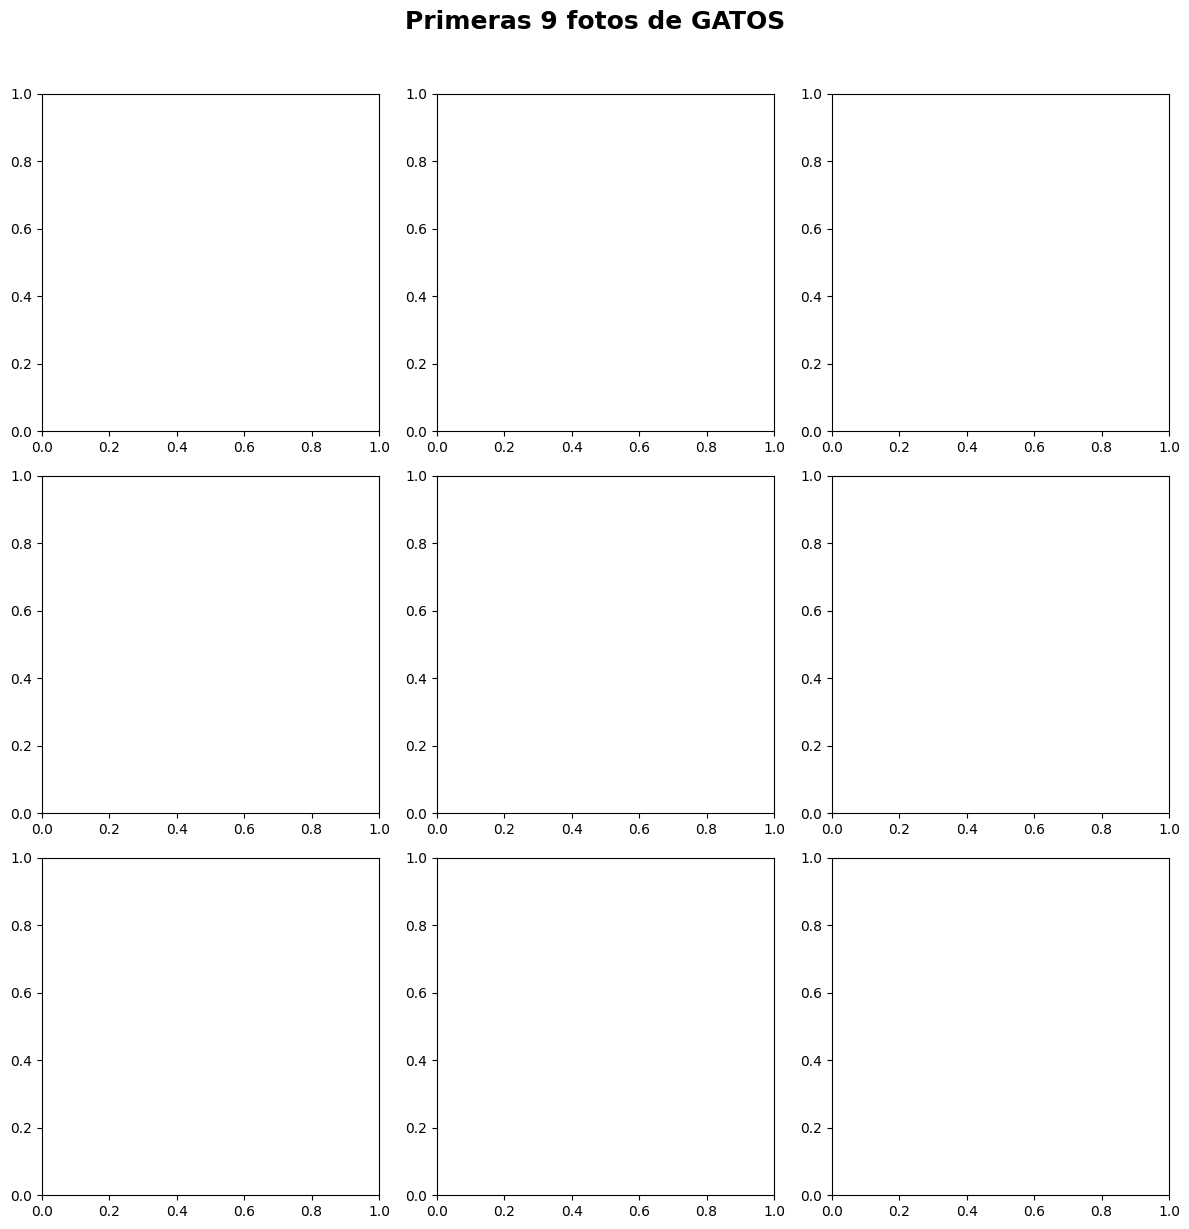

Las imágenes tienen tamaños diferentes. Se van a normalizar a 224 x 224 píxeles.

PERROS


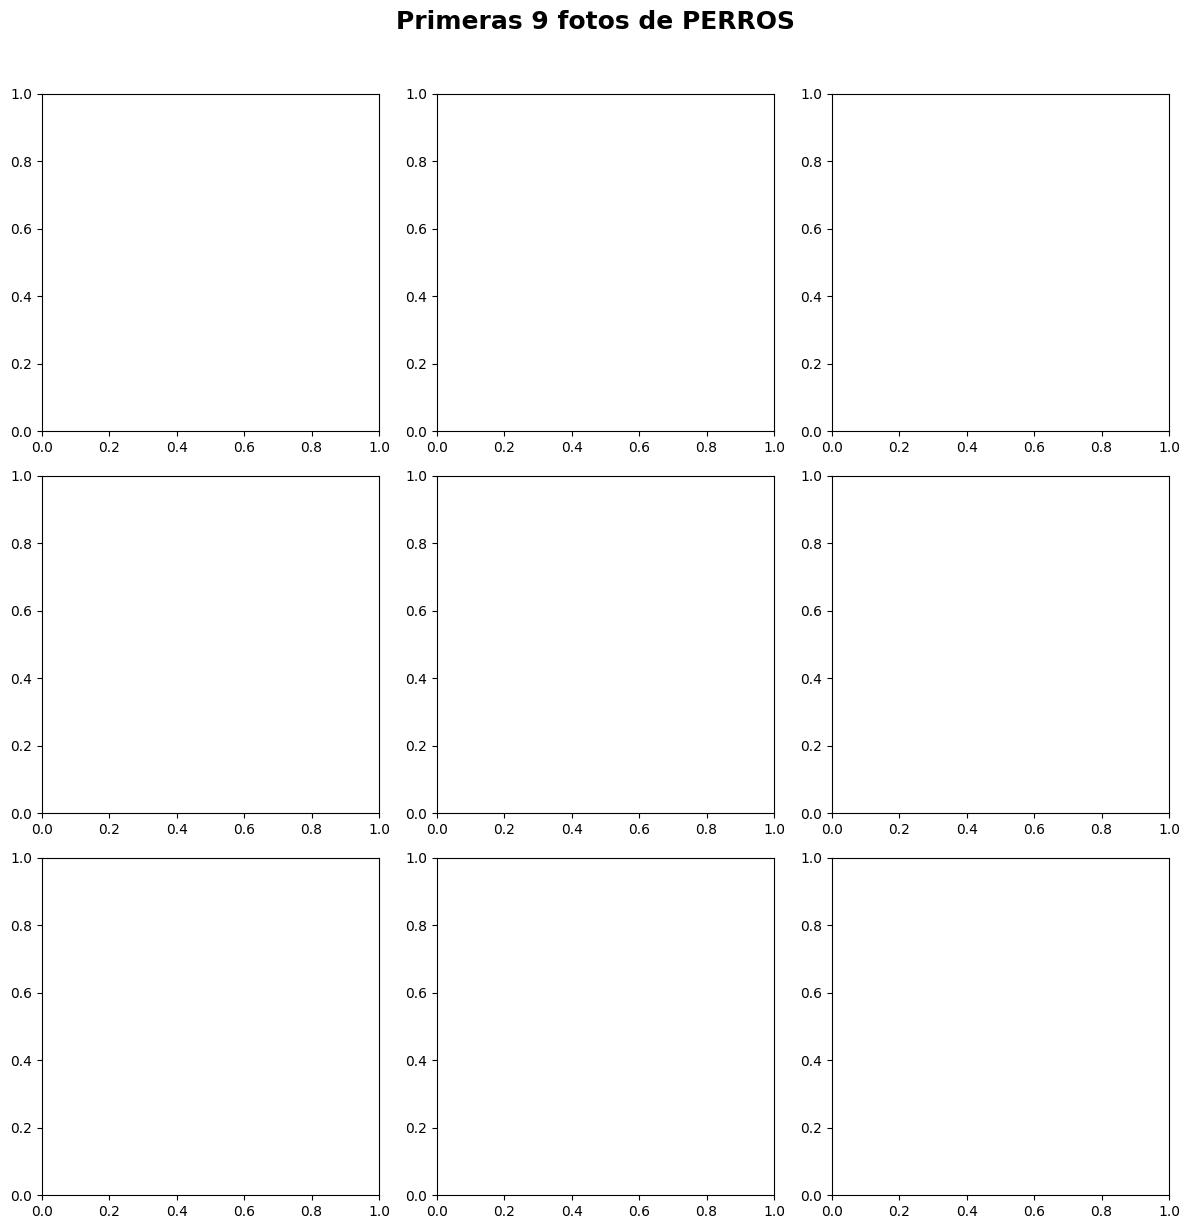

Las imágenes tienen tamaños diferentes. Se van a normalizar a 224 x 224 píxeles.


In [7]:
def mostrar_muestras(carpeta_clase, titulo, n_filas=3, n_cols=3):
    """
    Muestra una cuadrícula de imágenes de ejemplo de una clase.
    """
    imagenes = os.listdir(carpeta_clase)[:n_filas * n_cols]
    
    fig, axes = plt.subplots(n_filas, n_cols, figsize=(12, 12))
    fig.suptitle(titulo, fontsize=18, fontweight='bold', y=1.02)
    
    for i, (ax, nombre_imagen) in enumerate(zip(axes.flat, imagenes)):
        ruta = os.path.join(carpeta_clase, nombre_imagen)
        img  = Image.open(ruta)
        
        # Muestro la imagen
        ax.imshow(img)
        ax.set_title(f'Tamaño original:\n{img.size[0]} x {img.size[1]}px', fontsize=9)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f'Las imágenes tienen tamaños diferentes. Se van a normalizar a {IMG_ANCHO} x {IMG_ALTO} píxeles.')

# Quiero mostrar 9 gatos
print('GATOS')
mostrar_muestras(
    carpeta_clase = os.path.join(DATASET_PREPARADO, 'train', 'cat'),
    titulo = 'Primeras 9 fotos de GATOS'
)

# Quiero mostrar 9 perros
print('\nPERROS')
mostrar_muestras(
    carpeta_clase = os.path.join(DATASET_PREPARADO, 'train', 'dog'),
    titulo = 'Primeras 9 fotos de PERROS'
)

**Paso 5: Cargar las imágenes con ImageDataGenerator**

**Paso 6: Construcción de una RNA**

**Paso 7: Compilar el modelo**

**Paso 8: Configurar los callbacks**

**Paso 9: Entrenar el modelo**

**Paso 10: Visualizar el entrenamiento**

**Paso 11: Cargar el mejor modelo y evaluar**

**Paso 12: Hacer predicciones en imágenes nuevas**

**Paso 13: Guardar el modelo**